# Description

Google Colab notebook to run the SpeedyWeather model in Julia

To run Julia in Colab:
* Go to the Menu: Click on Runtime > Change runtime type.
* Select Julia: In the dropdown for "Runtime type," select Julia.

Note: takes around 5-6 minutes to load the SpeedyWeather package

Coded (poorly) by Matt Barlow. If you find any errors or have any improvements, please let me know at: Mathew_Barlow@uml.edu. I don't really know anything about Julia or SpeedyWeather, so there may be much better ways to do things.

Version history: </br>
* initial version: 22 Apr 2026




# Add needed packages

Installing the SpeedyWeather and plotting packages can take around ten minutes.

It appears to be possible to avoid installing the packages from scratch every time in colab, with an extra step:
https://zenn.dev/terasakisatoshi/articles/0b13997417282e?locale=en

In [5]:
using Pkg

In [6]:
# install SpeedyWeather in quiet mode
Pkg.add("SpeedyWeather"; io=devnull)
using SpeedyWeather

In [7]:
# for processing output
using SpeedyWeather.RingGrids
import SpeedyWeather.RingGrids: FullGaussianGrid

In [8]:
# install a plotting package
Pkg.add("PythonPlot"; io=devnull)

In [9]:
# for basic plotting
using Plots

In [10]:
# for calculating means, etc.
using Statistics

In [11]:
# for handling output
Pkg.add("NCDatasets"; io=devnull)
using NCDatasets

In [12]:
# for plotting
Pkg.add("CairoMakie"; io=devnull)
using CairoMakie


# initialize and run model

## simplest test case

run the wet primative equation model at T31L8 resolution for 10 days

seems to run faster on subsequent runs

In [13]:
spectral_grid = SpectralGrid(trunc=31, nlayers=8)   # define resolution
model = PrimitiveWetModel(spectral_grid)            # construct model
simulation = initialize!(model)                     # initialize all model components
run!(simulation, period=Day(10), output=true)       # aaaand action!

 run_0001 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:00:10 (2000-01-11, 217.67 years/day, 72 m/s, [-80, 40] ˚C)


let's pull out variables from the output

In [14]:
humid = simulation.diagnostic_variables.grid.humid_grid[:, 5]
ln_sfcp = simulation.diagnostic_variables.grid.pres_grid;

and make two quick heatmaps

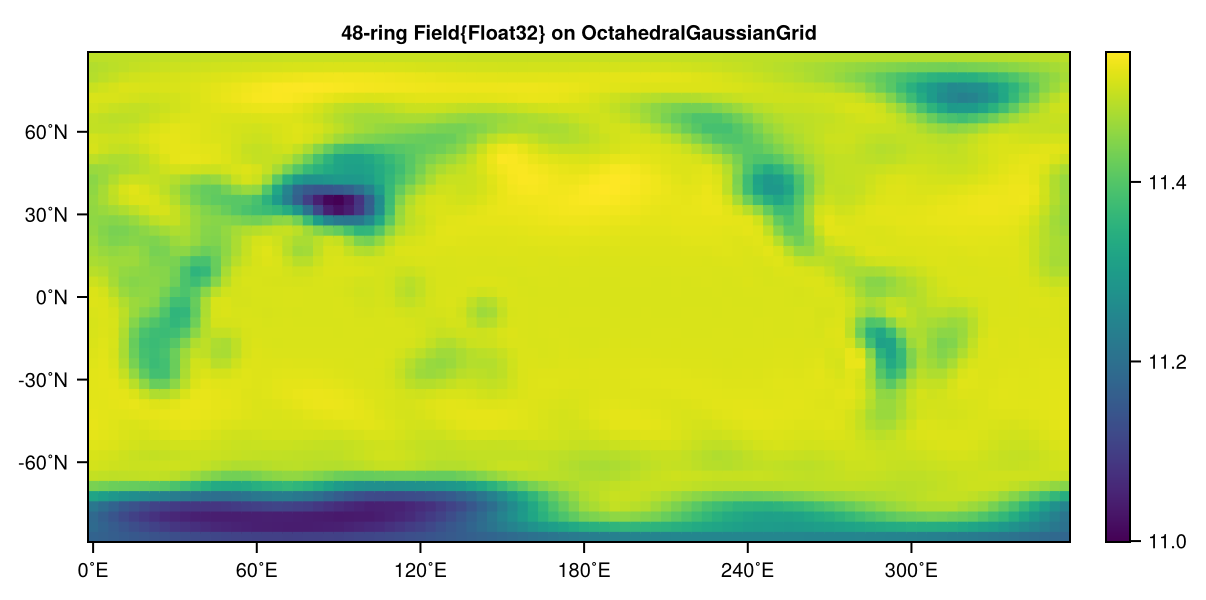

In [15]:
CairoMakie.heatmap(ln_sfcp)

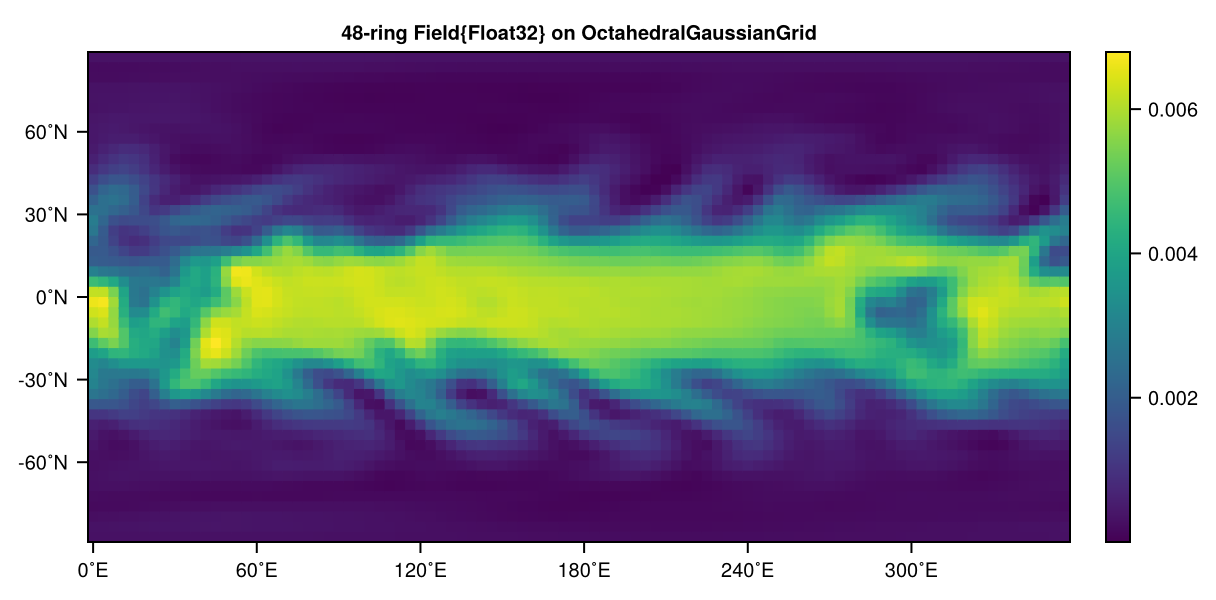

In [16]:
CairoMakie.heatmap(humid)

## modified test case with more output

now let's add a few bells and whistles:
*   run model in aquaplanet mode
*   netcdf output
*   additional output variables
*   transform output to pressure levels
*   a few more plots



Set up for adding variables to the default output (vertical velocity, geopotential, surface pressure). Since the latter two are already model variables, there's probably a shorter way to do it.

In [17]:
@kwdef struct VerticalVelocityOutput <: SpeedyWeather.AbstractOutputVariable
    name::String = "w"
    unit::String = "s^-1"
    long_name::String = "vertical velocity dσ/dt"
    dims_xyzt::NTuple{4, Bool} = (true, true, true, true)
end

SpeedyWeather.path(::VerticalVelocityOutput, simulation) =
    simulation.diagnostic_variables.dynamics.σ_tend

@kwdef struct SurfacePressureOutput <: SpeedyWeather.AbstractOutputVariable
    name::String = "pres"
    unit::String = "ln(pa)"
    long_name::String = "log of surface pressure"
    dims_xyzt::NTuple{4, Bool} = (true, true, false, true)
    missing_value::Float32 = NaN32
end

SpeedyWeather.path(::SurfacePressureOutput, simulation) =
    simulation.diagnostic_variables.grid.pres_grid

@kwdef struct GeopotentialOutput <: SpeedyWeather.AbstractOutputVariable
    name::String = "geopotential"
    unit::String = "m^2s^-2"
    long_name::String = "geopotential"
    dims_xyzt::NTuple{4, Bool} = (true, true, true, true)
    missing_value::Float32 = NaN32
end

SpeedyWeather.path(::GeopotentialOutput, simulation) =
    simulation.diagnostic_variables.grid.geopotential

run model as aquaplanet, T42L8, with netcdf output, and vertical velocity and surface pressure added to the default variables

In [44]:
spectral_grid = SpectralGrid(trunc=42, nlayers=8)   # define resolution
output = NetCDFOutput(spectral_grid)   # set up netcdf output
add!(output, VerticalVelocityOutput()) # add output variable
add!(output, SurfacePressureOutput())  # add output variable
add!(output, GeopotentialOutput())     # add output variable

# configure ocean, land-sea masks, and orography for aquaplanet
ocean = AquaPlanet(spectral_grid, temp_equator=302, temp_poles=273)
land_sea_mask = AquaPlanetMask(spectral_grid)
orography = NoOrography(spectral_grid)

model = PrimitiveWetModel(spectral_grid; ocean, land_sea_mask, orography, output)

simulation = initialize!(model)         # initialize all model components
run!(simulation, period=Day(10), output=true)  # run


 run_0004 100% ━━━━━━━━━━━━━━━━━━━━  Time: 0:00:20 (2000-01-11, 115.92 years/day, 42 m/s, [-72, 21] ˚C)


two quick heatmaps, as before

In [45]:
humid = simulation.diagnostic_variables.grid.humid_grid[:, 5]
ln_sfcp = simulation.diagnostic_variables.grid.pres_grid;

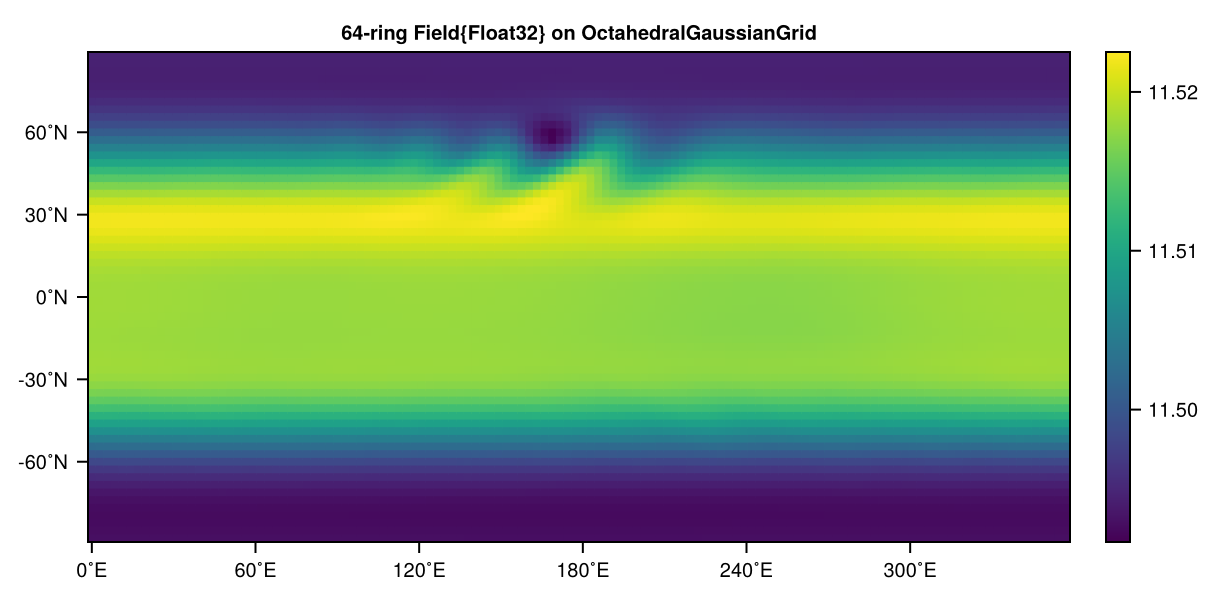

In [46]:
CairoMakie.heatmap(ln_sfcp)

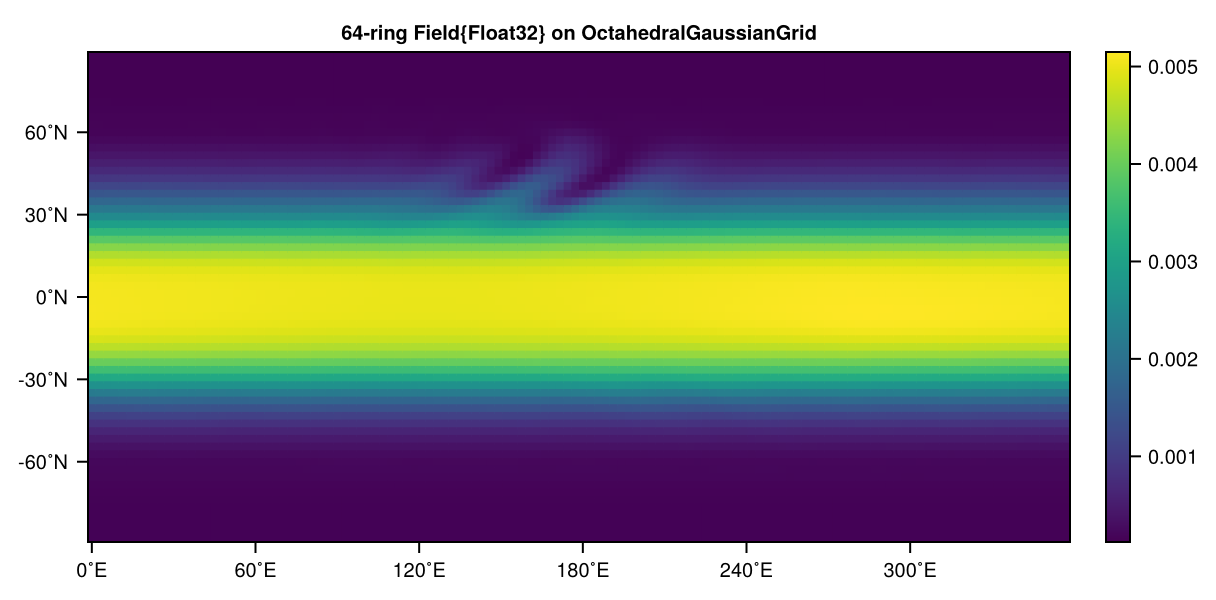

In [47]:
humid = simulation.diagnostic_variables.grid.humid_grid[:, 5]
CairoMakie.heatmap(humid)

get the netcdf output as a dataset

In [48]:
path = joinpath(model.output.run_path, model.output.filename)
ds = NCDataset(path);

output is on sigma levels, so define a function to interpolate to pressure levels (based on documentation, but changed slightly)

In [49]:
function interpolate_pressure_levels(A::AbstractArray{T,3},pₛ::AbstractMatrix,σ::AbstractVector,p::Real) where T
    nx,ny,nlev = size(A)
    B = zeros(T,nx,ny)

    for i in 1:nx
        for j in 1:ny
            σij = p/pₛ[i,j]
            if σij < σ[1]
                B[i,j] = A[i,j,1]*NaN
            elseif σij >= σ[end]
                B[i,j] = A[i,j,end]*NaN
            else
                k = 1
                while (σ[k] < σij) k += 1 end
                Δσ = σ[k] - σ[k-1]       # level thickness
                w1 = (σ[k] - σij)/Δσ     # weight for k-1 level
                w2 = (σij - σ[k-1])/Δσ   # weight for k level
                B[i,j] = w1*A[i,j,k-1] + w2*A[i,j,k]
            end
        end
    end

    return B
end

interpolate_pressure_levels (generic function with 1 method)

interpolate a few variables from sigma to pressure levels

In [50]:
vor_end = ds["vor"][:, :, :, end]
pres_end = exp.(ds["pres"][:, :, end]) # pres is log(sfc pressure)
sigma = ds["layer"]

vort500 = interpolate_pressure_levels(vor_end, pres_end, sigma, 50000)

geo_end = ds["geopotential"][:, :, :, end]
hgt500 = interpolate_pressure_levels(geo_end, pres_end, sigma, 50000.0)/9.8;

plot 500 hPa heights

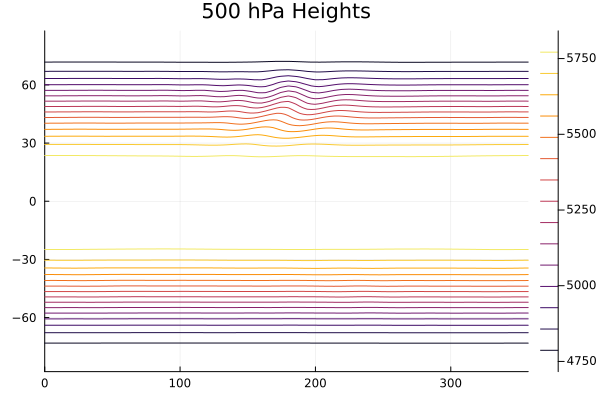

In [51]:
# note: data is stored nx, ny, nz, nt
# plotting routine is expecting ny, ny
# and latitude increasing

lon = ds["lon"]
lat = ds["lat"]
lat = reverse(lat)

var = hgt500' # quote mark takes transpose
var = reverse(var, dims=1)

Plots.contour(lon, lat, var, title="500 hPa Heights")

plot 500 hPa vorticity

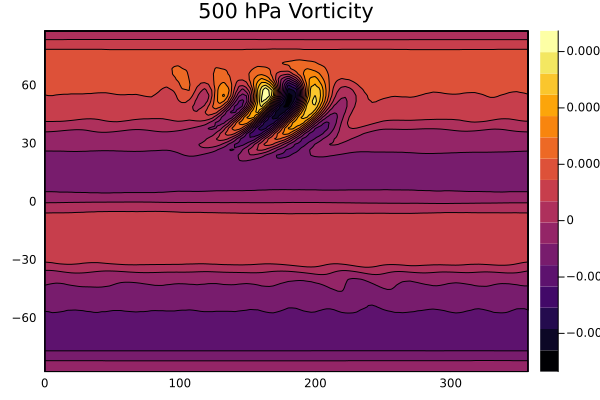

In [52]:
# note: data is stored nx, ny, nz, nt
# plotting routine is expecting ny, ny
# and latitude increasing

lon = ds["lon"]
lat = ds["lat"]
lat = reverse(lat)

var = vort500' # quote mark takes transpose
var = reverse(var, dims=1)

Plots.contourf(lon, lat, var, title="500 hPa Vorticity")